<a href="https://colab.research.google.com/github/Golu-yadav-2007/algo-strategies-mini-project-Kartik-Yadav/blob/main/Notebooks/algo_strategies_notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import time
import numpy as np
import matplotlib.pyplot as plt
import random
import sys

# Setting recursion limit for deep DP problems
sys.setrecursionlimit(2000)

print("Environment Ready: Libraries Loaded.")

Environment Ready: Libraries Loaded.


In [ ]:
def merge_sort_latency(data):
    """Sorts network latency packets using Merge Sort."""
    if len(data) <= 1:
        return data

    mid = len(data) // 2
    left = merge_sort_latency(data[:mid])
    right = merge_sort_latency(data[mid:])

    return merge(left, right)

def merge(left, right):
    result = []
    i = j = 0
    while i < len(left) and j < len(right):
        if left[i] < right[j]:
            result.append(left[i])
            i += 1
        else:
            result.append(right[j])
            j += 1
    result.extend(left[i:])
    result.extend(right[j:])
    return result

# Test
test_latencies = [120, 45, 300, 15, 88, 200]
print(f"Sorted Latencies: {merge_sort_latency(test_latencies)}")

Sorted Latencies: [15, 45, 88, 120, 200, 300]


In [ ]:
def greedy_routing(graph, start):
    """Simulates finding the next best hop in a network routing table."""
    visited = {start}
    path = [start]
    current = start

    while len(visited) < len(graph):
        # Find the nearest neighbor not yet visited (Greedy choice)
        next_node = None
        min_dist = float('inf')

        for neighbor, weight in graph[current].items():
            if neighbor not in visited and weight < min_dist:
                min_dist = weight
                next_node = neighbor

        if not next_node: break
        visited.add(next_node)
        path.append(next_node)
        current = next_node

    return path

# Example Network Graph
network = {
    'NodeA': {'NodeB': 2, 'NodeC': 5},
    'NodeB': {'NodeA': 2, 'NodeC': 1, 'NodeD': 8},
    'NodeC': {'NodeA': 5, 'NodeB': 1, 'NodeD': 3},
    'NodeD': {'NodeB': 8, 'NodeC': 3}
}
print(f"Greedy Route: {greedy_routing(network, 'NodeA')}")

Greedy Route: ['NodeA', 'NodeB', 'NodeC', 'NodeD']


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
def allocate_bandwidth(capacity, weights, priorities, n):
    """DP approach to maximize data priority within bandwidth limits."""
    dp = [[0 for _ in range(capacity + 1)] for _ in range(n + 1)]

    for i in range(1, n + 1):
        for w in range(capacity + 1):
            if weights[i-1] <= w:
                dp[i][w] = max(priorities[i-1] + dp[i-1][w-weights[i-1]], dp[i-1][w])
            else:
                dp[i][w] = dp[i-1][w]

    return dp[n][capacity]

# Data: (Required Bandwidth, Priority Level)
bw_needed = [10, 20, 30]
priority = [60, 100, 120]
max_bw = 50
print(f"Max Priority Achieved: {allocate_bandwidth(max_bw, bw_needed, priority, len(priority))}")

Max Priority Achieved: 220


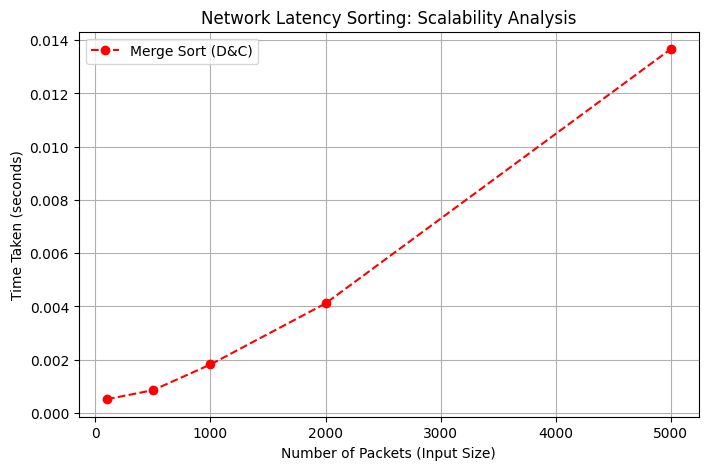

In [ ]:
def benchmark_sorting():
    sizes = [100, 500, 1000, 2000, 5000]
    times = []

    for s in sizes:
        arr = [random.randint(1, 10000) for _ in range(s)]
        start = time.time()
        merge_sort_latency(arr)
        times.append(time.time() - start)

    plt.figure(figsize=(8, 5))
    plt.plot(sizes, times, marker='o', linestyle='--', color='r', label='Merge Sort (D&C)')
    plt.title('Network Latency Sorting: Scalability Analysis')
    plt.xlabel('Number of Packets (Input Size)')
    plt.ylabel('Time Taken (seconds)')
    plt.grid(True)
    plt.legend()
    plt.show()

benchmark_sorting()